# AGHRI Person Re-Identification Benchmark

This notebook summarises the saved AGHRI OCLReID comparison results using the three main metrics only: `Success@0.5`, `Mean IoU`, and `Prediction availability`.

The comparison includes three methods:

- `rpf-ReID`
- `Normal part-OCLReID`
- `Gated part-OCLReID`

The figures shown here are the selected saved figures from `results/final_comparison/figures`. The figures are embedded in this notebook so they display even when Jupyter is opened from the `notebooks/` folder.


## Methods Compared

The results compare three ReID-based target-selection methods.

| Method name in figures | Repository wrapper | Runtime method / setting | Explanation |
|---|---|---|---|
| `rpf-ReID` | `methods/rpf_reid/` | `rpf-ReID` | Baseline ReID method used for comparison. |
| `Normal part-OCLReID` | `methods/normal_part_oclreid/` | `part-OCLReID` | Original part-aware OCLReID runtime using the released ResNet18 ReID checkpoint. |
| `Gated part-OCLReID` | `methods/gated_part_oclreid/` | `part-OCLReID` with `--association-mode reid_gate` | Normal part-OCLReID plus a ReID-gated target reassociation fallback when the normal method has no selected target. |

The gated method is not a separate tracker. It keeps the same tracker state, online learning, prediction format, frame mapping, and evaluation logic as Normal part-OCLReID. The gate is only used as a fallback to reassociate the known target identity to an existing track when the normal target selection is empty.

The frozen gate settings used for the saved results are:

| Setting | Value |
|---|---:|
| `association-reid-threshold` | 0.60 |
| `association-reid-margin` | 0.02 |
| `association-min-bbox-score` | 0.0 |
| `association-min-visible-parts` | 1 |


## Metrics Used

All three metrics are reported as proportions from 0 to 1, where higher is better.

| Metric | Meaning |
|---|---|
| `Success@0.5` | Fraction of ground-truth-visible frames where the predicted target overlaps the ground-truth box with IoU >= 0.5. |
| `Mean IoU` | Average intersection-over-union between the predicted target box and the ground-truth target box over visible frames. |
| `Prediction availability` | Fraction of ground-truth-visible frames where the method outputs a target prediction. |


## Test Data Used

The main results table and the full-test metric figures use all six final-test bags:

| Test bag | Scenario | Humans | Robot motion |
|---|---|---:|---|
| `footpath1_p1_nj+mk+gl_1walk+check_mv_11_12_2024_1_label` | Footpath | 1 | Moving |
| `footpath1_p1_oj+mk+gl_1walk+check_st_11_12_2024_1_label` | Footpath | 1 | Stationary |
| `in_straw_3pick_diff_st_10_24_2024_5_a_label` | Polytunnel | 3 | Stationary |
| `out_straw_1push_1walk_1swap_st_11_07_2024_1_b_label` | Polytunnel | 3 | Stationary |
| `out_vine_1push_3carry_st_ly_11_06_2024_1_label` | Vineyard | 4 | Stationary |
| `out_vine_4swap+walk_st_ly_11_06_2024_2_label` | Vineyard | 4 | Stationary |

Figure 2 is the exception among the metric figures: it uses one selected representative bag for each scenario rather than all six bags.

| Scenario | Selected bag used in Figure 2 |
|---|---|
| Footpath | `footpath1_p1_oj+mk+gl_1walk+check_st_11_12_2024_1_label` |
| Polytunnel | `in_straw_3pick_diff_st_10_24_2024_5_a_label` |
| Vineyard | `out_vine_4swap+walk_st_ly_11_06_2024_2_label` |

The qualitative figures are selected visual examples, not aggregate metric plots.


## Main Results Table

| Method | Completed runs | Success@0.5 | Mean IoU | Prediction availability |
|---|---:|---:|---:|---:|
| rpf-ReID | 50 | 0.360 | 0.322 | 0.377 |
| Normal part-OCLReID | 50 | 0.483 | 0.428 | 0.546 |
| Gated part-OCLReID | 50 | 0.557 | 0.494 | 0.648 |

**Key observation.** Compared with Normal part-OCLReID, Gated part-OCLReID improves Success@0.5 by 0.073, Mean IoU by 0.066, and Prediction availability by 0.102. Compared with rpf-ReID, the corresponding improvements are 0.196, 0.171, and 0.271.


In [ ]:
# Optional reproducibility cell: load the main table from the saved CSV.
from pathlib import Path
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
results_csv = ROOT / "results" / "final_comparison" / "overall_method_comparison.csv"
main_table = pd.read_csv(results_csv)
main_table = main_table[[
    "method",
    "completed_runs",
    "success_iou_0_5",
    "mean_iou",
    "prediction_availability",
]].rename(columns={
    "method": "Method",
    "completed_runs": "Completed runs",
    "success_iou_0_5": "Success@0.5",
    "mean_iou": "Mean IoU",
    "prediction_availability": "Prediction availability",
})
main_table


## Figure 1: Overall Whole-Test Core Metrics

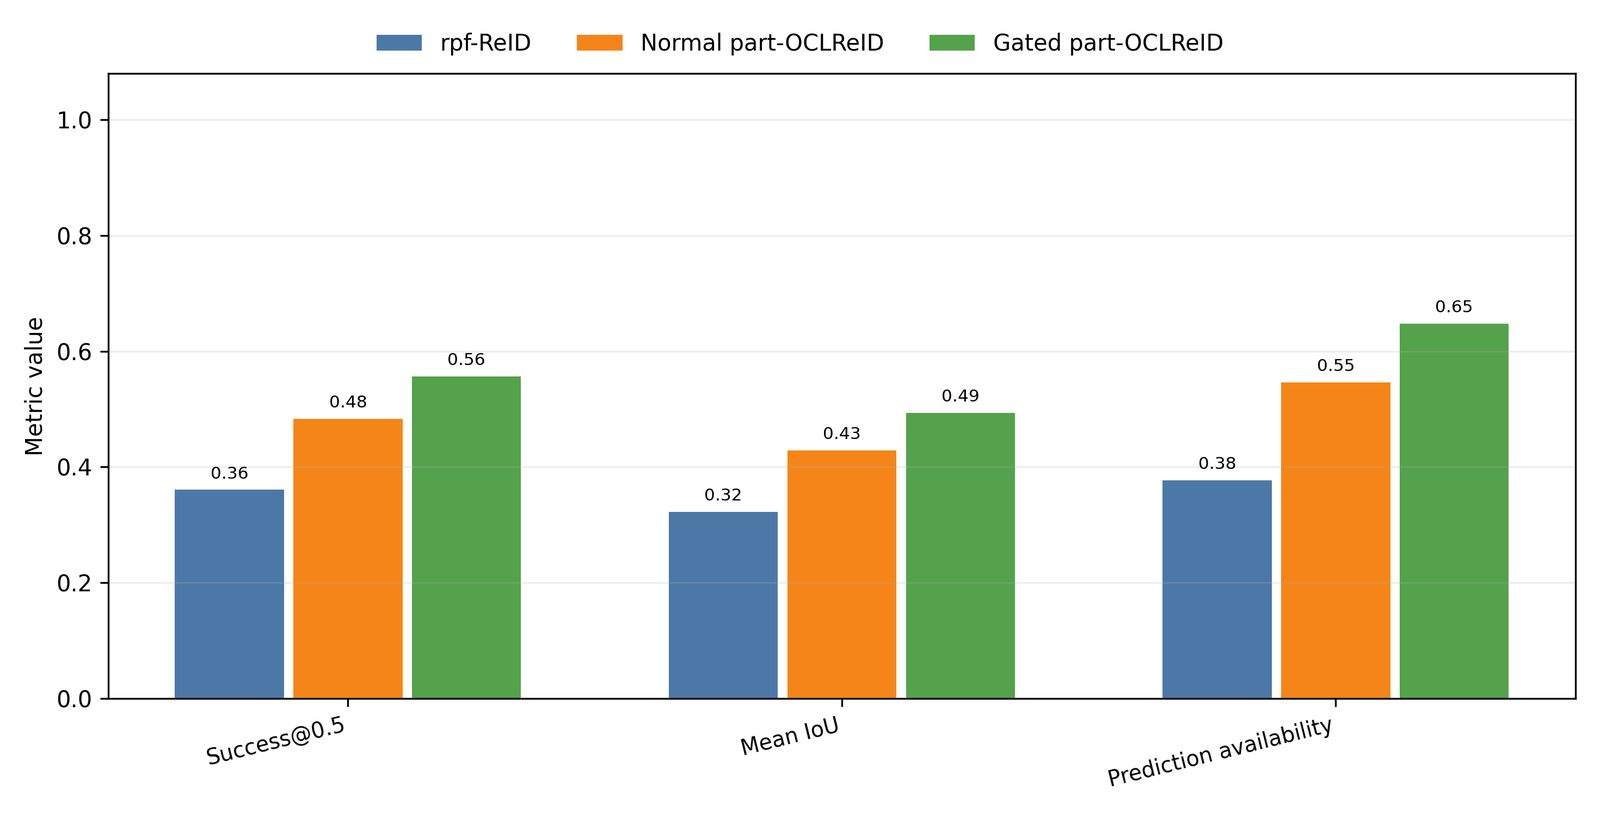

This figure shows the full six-bag test comparison across the three main metrics. Gated part-OCLReID has the highest values for `Success@0.5`, `Mean IoU`, and `Prediction availability`. Normal part-OCLReID also improves clearly over rpf-ReID, while the gated method adds another gain by recovering targets that the normal method would otherwise leave unselected.


## Figure 2: Scenario-Level Core Metrics

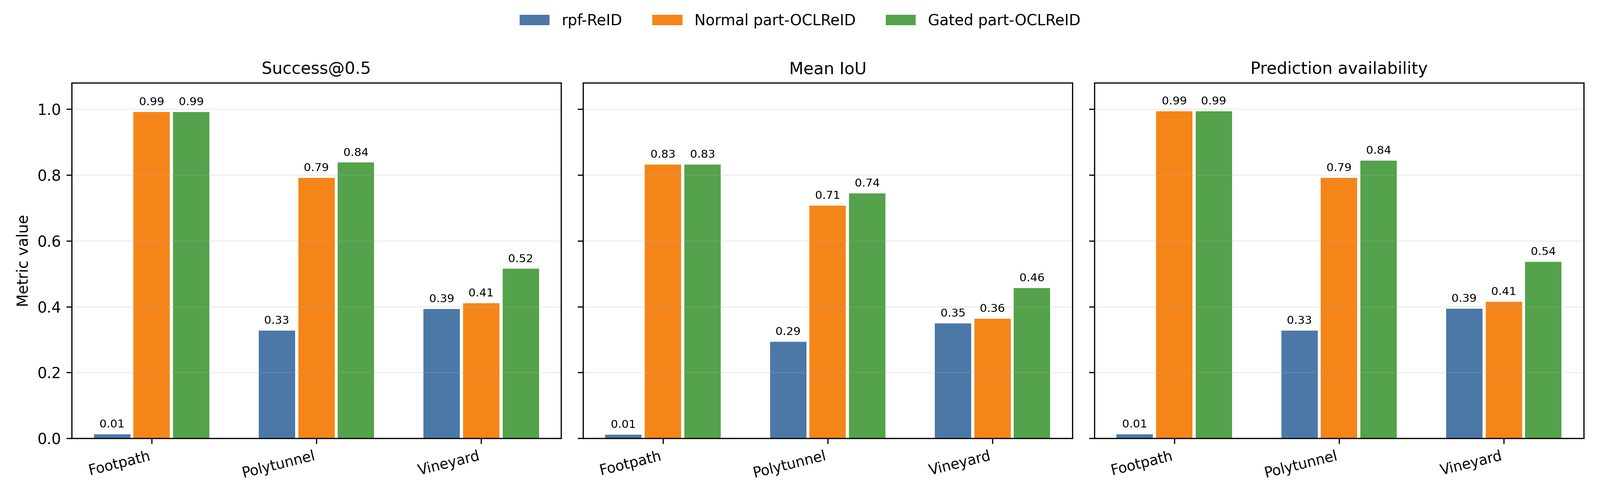

This figure groups the three metrics by selected representative environments: footpath, polytunnel, and vineyard. The selected bags are `footpath1_p1_oj+mk+gl_1walk+check_st_11_12_2024_1_label`, `in_straw_3pick_diff_st_10_24_2024_5_a_label`, and `out_vine_4swap+walk_st_ly_11_06_2024_2_label`. The footpath case is easiest for the part-based methods, polytunnel performance is also strong, and vineyard is more difficult. The gated method gives the clearest vineyard improvement, especially in `Success@0.5` and `Prediction availability`.


## Figure 3: Human-Count Breakdown

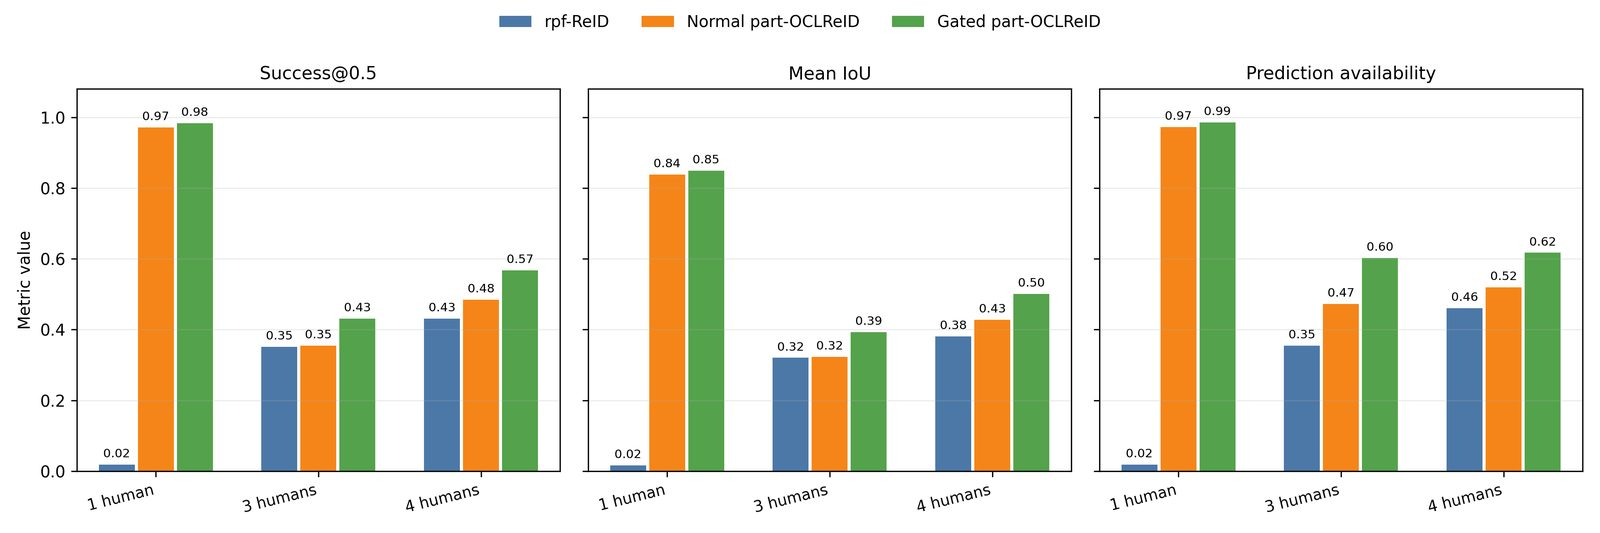

This full-test figure groups the results by the number of people in the scene: the two footpath bags have one human, the two polytunnel bags have three humans, and the two vineyard bags have four humans. The single-human scenes are close to solved by the part-based methods. The three-human and four-human settings are harder because there are more possible identity confusions and occlusions. Gated part-OCLReID improves availability and localization in the more crowded settings.


## Figure 4: Robot-Motion Breakdown

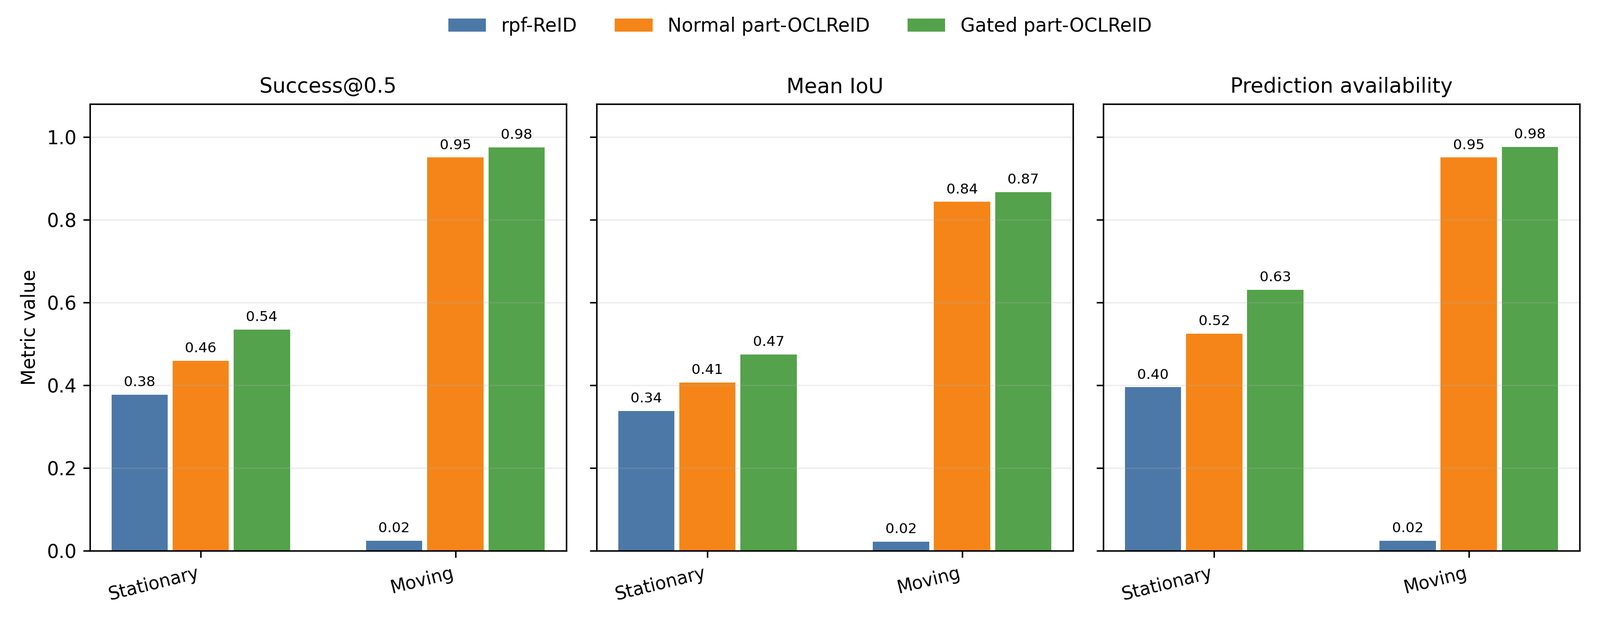

This full-test figure separates stationary and moving robot runs. The moving group comes from the `check_mv` footpath bag, while the stationary group comes from the `check_st` footpath bag and the four polytunnel and vineyard bags. The moving cases are strong for normal and gated part-OCLReID, while rpf-ReID struggles. In stationary runs, the gated method still improves the three main metrics.


## Figure 5: Camera-Level Breakdown

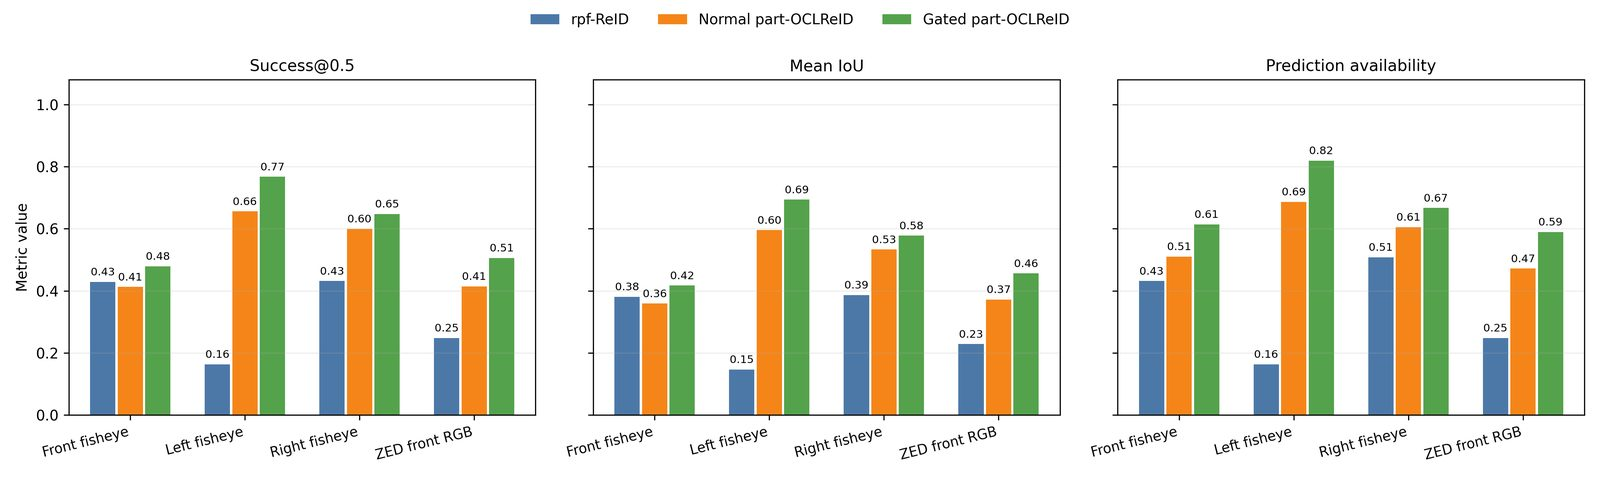

This full-test figure compares the camera streams across all six bags. Performance varies across fisheye and ZED RGB views, reflecting differences in viewpoint, distortion, target scale, and occlusion. Gated part-OCLReID is consistently the strongest of the three methods across the cameras for the three main metrics.


## Qualitative Examples

The qualitative figures use the same visual convention:

- Green box: selected target.
- Red boxes: other tracked people.
- `TARGET LOST`: no target is selected for that method at that frame.

These examples are included to make the metric differences easier to interpret visually.


### Figure 6: ZED Front RGB Qualitative Examples

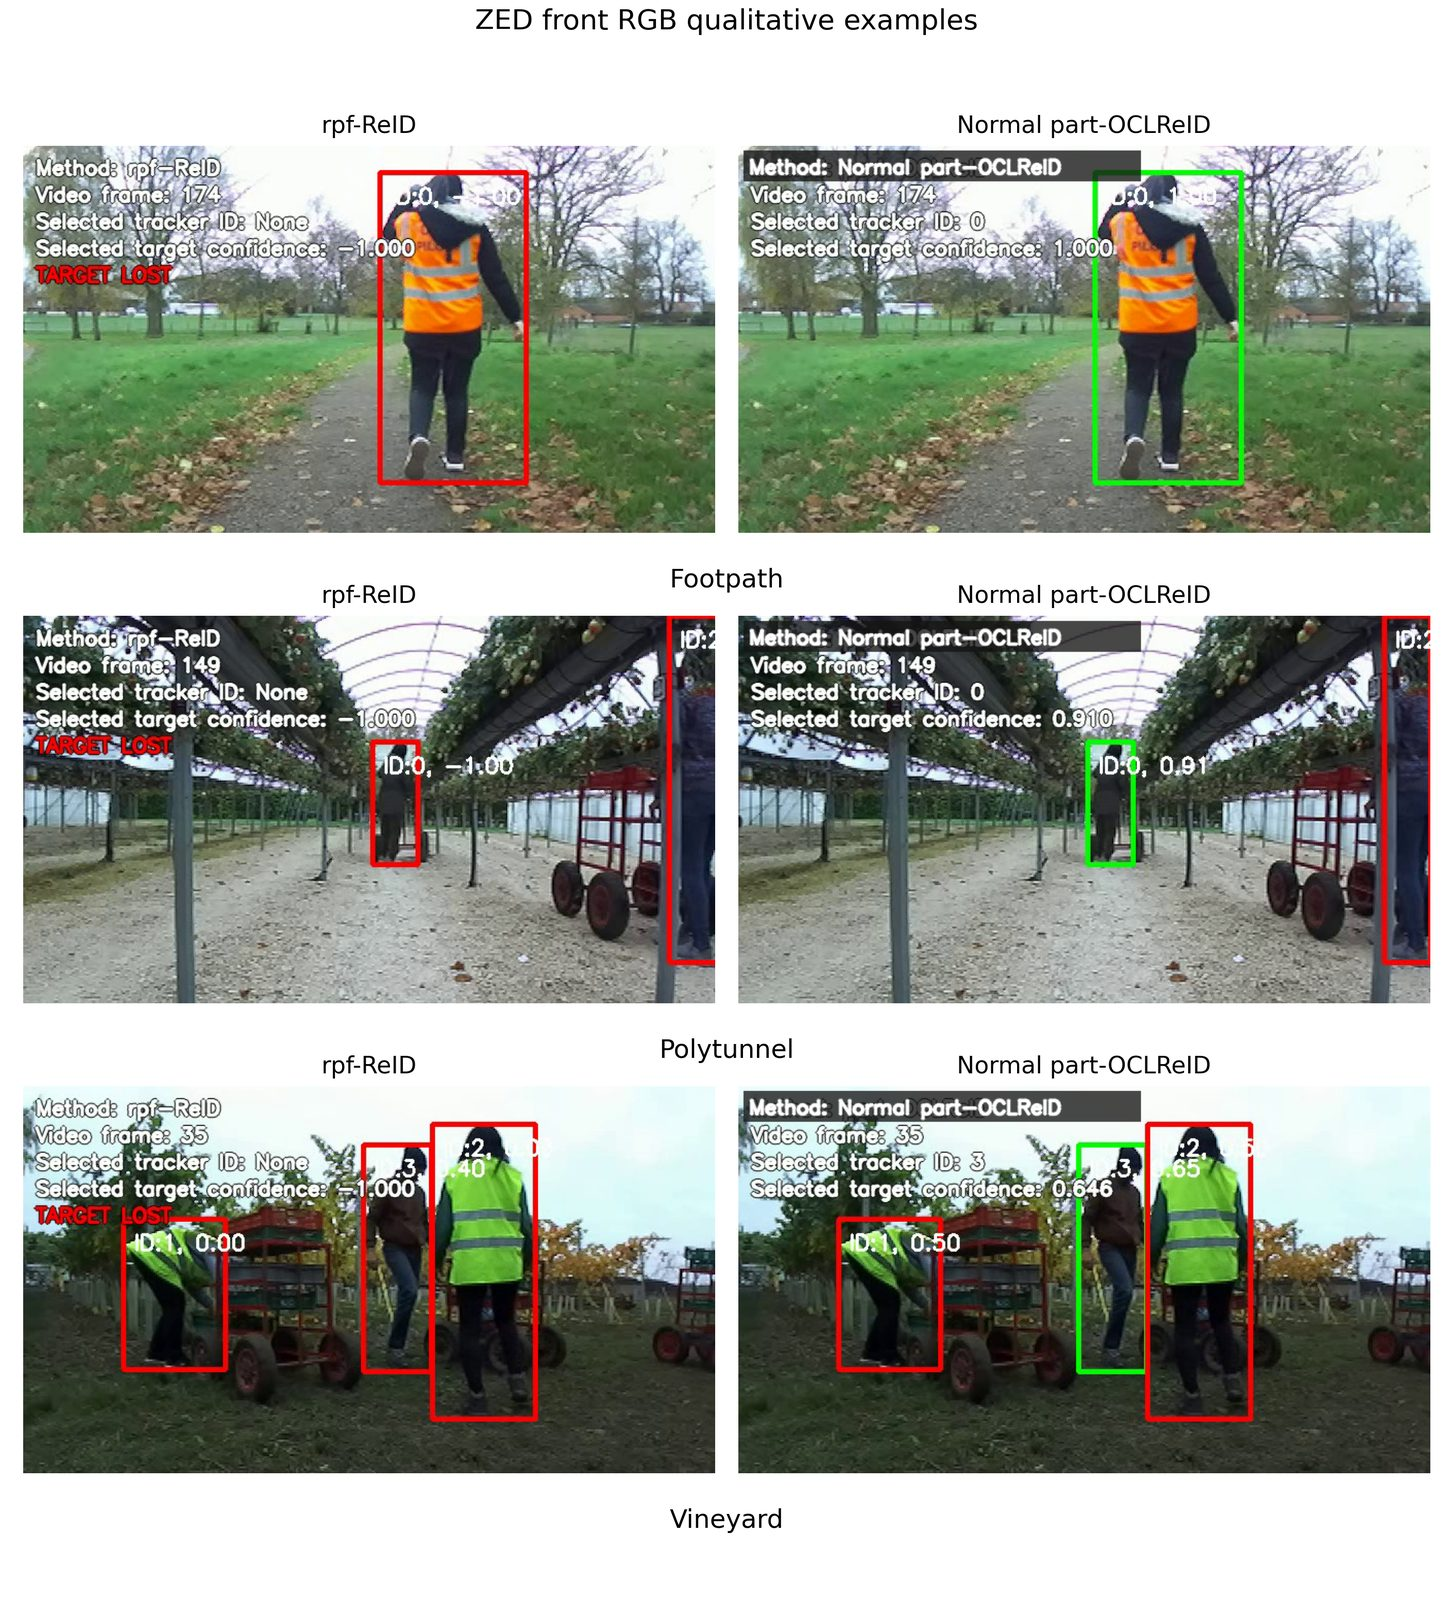

This figure compares rpf-ReID and Normal part-OCLReID on ZED front RGB examples from footpath, polytunnel, and vineyard environments. The examples show cases where rpf-ReID loses the target or does not select it, while Normal part-OCLReID is able to keep or recover the selected target in green.


### Figure 7: Front Fisheye Qualitative Examples

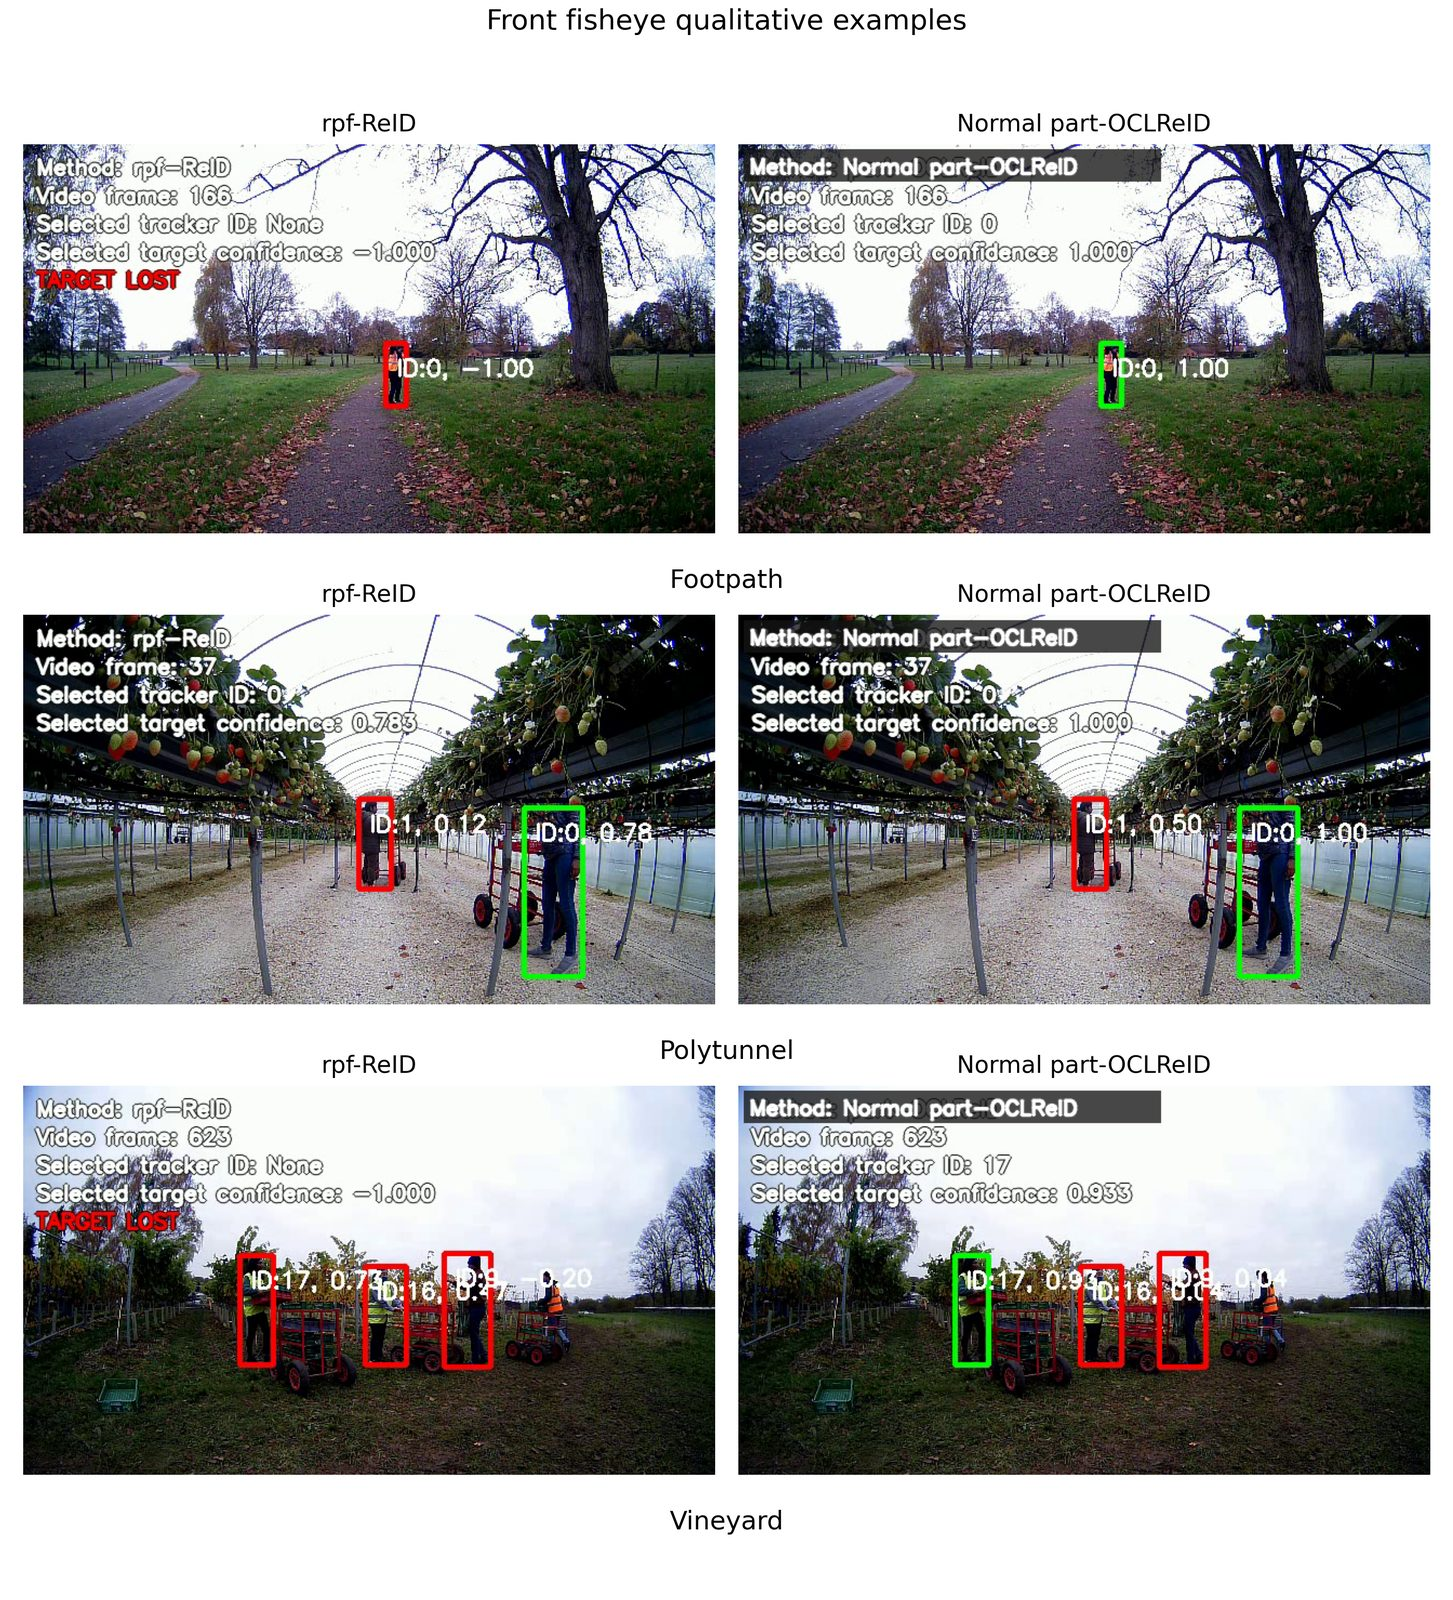

This figure gives the same type of comparison for the front fisheye camera. The wider view can include more people and stronger distortion, but it can also preserve more scene context. The examples show Normal part-OCLReID selecting the target more reliably than rpf-ReID in several challenging views.


### Figure 8: ReID-Gated Reassociation Example

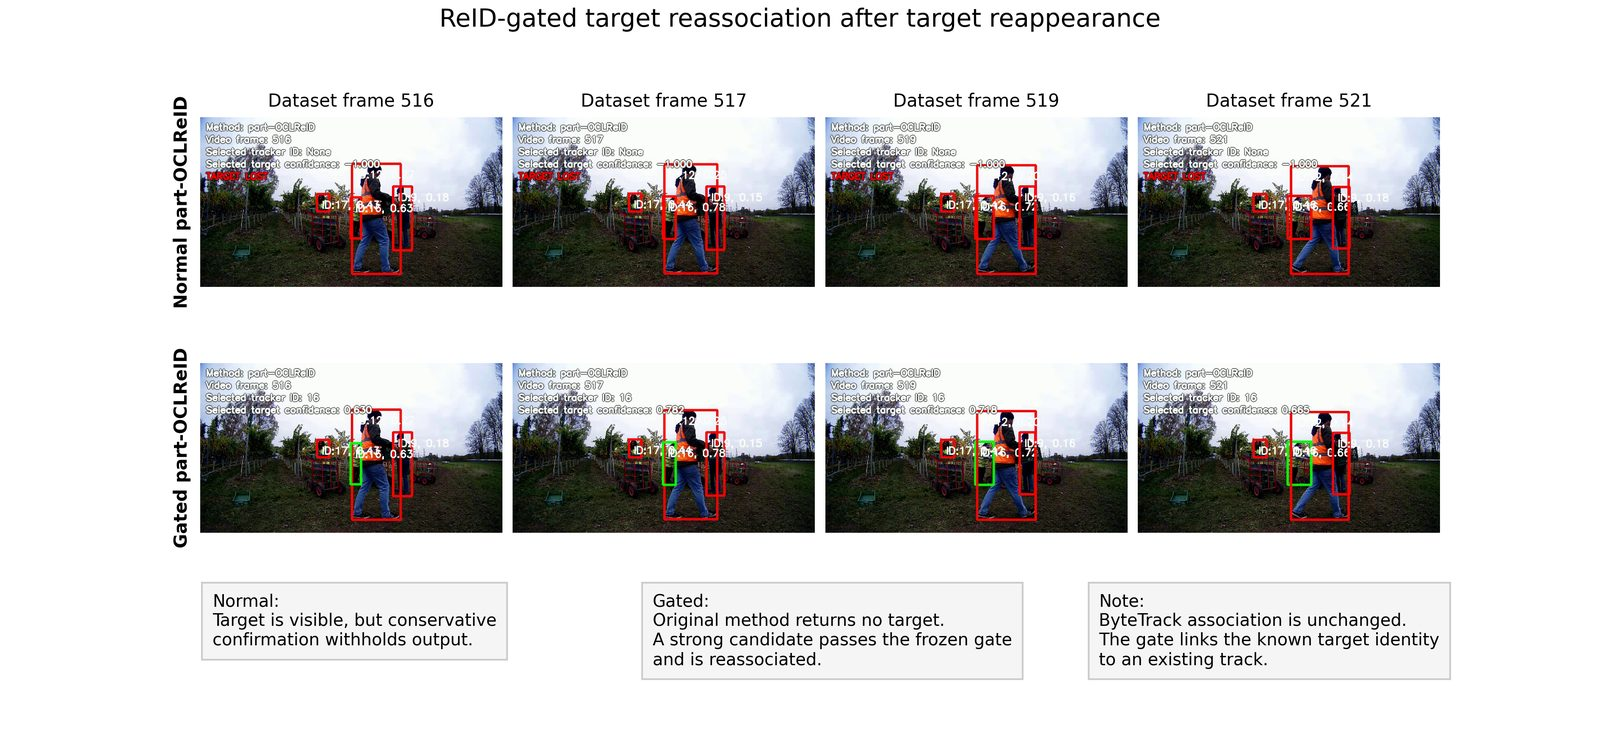

This figure focuses on the difference between Normal part-OCLReID and Gated part-OCLReID after target reappearance. In the top row, the normal method keeps the target unselected even though the target is visible. In the bottom row, the gated method links the known target identity to an existing track and restores the selected target box. This explains why the gated method improves `Prediction availability` and also improves `Success@0.5` and `Mean IoU` when the reassociated track is correct.


## Summary

Across the saved AGHRI test results, Gated part-OCLReID performs best on the three main metrics. The full-test quantitative figures show that this improvement is visible across human-count, robot-motion, and camera breakdowns, while the selected-scenario figure shows the same comparison on one representative bag per environment. The qualitative examples show the practical reason for the gain: the gated method can recover a target selection after the normal method has returned no target.
